# 01 — Baseline Reproduction (Meijer et al. 2021)

Goal: Load the published Meijer 2021 outputs, understand the data, and verify our
baseline model implementation against the published results.

Target: R² within 10% of the published value (~0.71 on 51 observed fluxes).

In [5]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")

## 1. Load Meijer 2021 shapefile

In [6]:
shp = gpd.read_file(DATA_RAW / "meijer2021" / "Meijer2021_midpoint_emissions.shp")
shp = shp.rename(columns={"dots_exten": "emission_ton"})
shp["lon"] = shp.geometry.x
shp["lat"] = shp.geometry.y
print(f"Rivers: {len(shp):,}")
print(f"Columns: {list(shp.columns)}")
shp.describe()

Rivers: 31,819
Columns: ['emission_ton', 'geometry', 'lon', 'lat']


,emission_ton,lon,lat
count,31819.000000,31819.000000,31819.000000
mean,31.615832,66.487344,11.065975
std,416.877329,76.568565,18.560880
min,0.000000,-135.327083,-54.882083
25%,0.334101,9.485000,-1.580833
50%,1.294220,101.963750,10.184583
75%,7.243510,122.238750,20.205625
max,62591.900000,179.947083,59.803750


## 2. Explore emission distribution

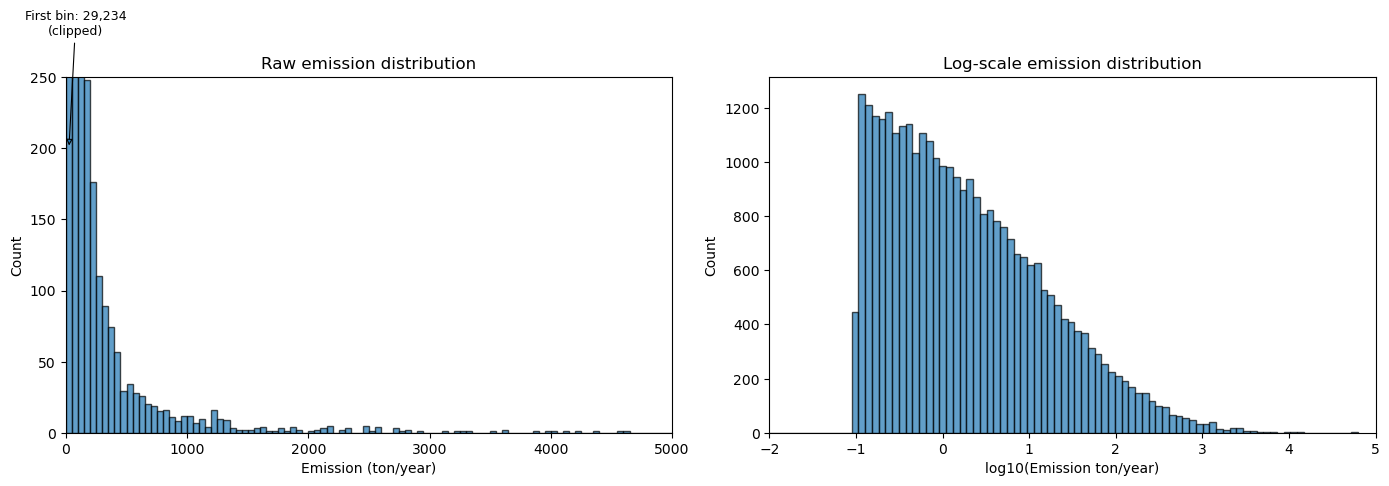

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_emission = np.log10(shp["emission_ton"].clip(lower=1e-3))

counts, bin_edges = np.histogram(shp["emission_ton"], bins=100, range=(0, 5000))
axes[0].hist(
    shp["emission_ton"],
    bins=bin_edges,
    edgecolor="black",
    alpha=0.7,
)
axes[0].set_xlim(0, 5000)
axes[0].set_ylim(0, 250)  # clip y so tail bins visible
axes[0].set_xlabel("Emission (ton/year)")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw emission distribution")
axes[0].annotate(
    f"First bin: {counts[0]:,}\n(clipped)",
    xy=(bin_edges[1] / 2, 200),
    xytext=(80, 280),
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="-|>", lw=0.8),
)

axes[1].hist(log_emission, bins=100, edgecolor="black", alpha=0.7)
axes[1].set_xlim(-2, np.ceil(log_emission.max()))
axes[1].set_xlabel("log10(Emission ton/year)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-scale emission distribution")

plt.tight_layout()
plt.savefig("../results/figures/01_emission_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Global map of river outfalls

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
shp.plot(
    ax=ax,
    column="emission_ton",
    cmap="YlOrRd",
    legend=True,
    markersize=1,
    norm=plt.matplotlib.colors.LogNorm(vmin=0.01, vmax=shp.emission_ton.max()),
    legend_kwds={"label": "Emission (ton/year)", "shrink": 0.6},
)
ax.set_title("Meijer 2021 — Global River Plastic Emissions")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("../results/figures/01_global_emissions_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Top-emitting rivers

In [ ]:
top100 = shp.nlargest(100, "emission_ton")
total = shp.emission_ton.sum()
top100_share = top100.emission_ton.sum() / total * 100
top1000 = shp.nlargest(1000, "emission_ton")
top1000_share = top1000.emission_ton.sum() / total * 100

print(f"Total emissions: {total:,.0f} ton/year")
print(f"Top 100 rivers: {top100_share:.1f}% of total")
print(f"Top 1000 rivers: {top1000_share:.1f}% of total")
print(f"\nTop 10:")
print(top100[["emission_ton", "lon", "lat"]].head(10).to_string())

## 5. Regional breakdown

In [ ]:
def assign_region(lat, lon):
    if lat > 20 and -130 < lon < -60:
        return "North America"
    if lat < 20 and -80 < lon < -35:
        return "Central/South America"
    if -35 < lat < 37 and -20 < lon < 55:
        return "Africa"
    if lat > 37 and -20 < lon < 55:
        return "Europe"
    if lat > 0 and 55 < lon < 145:
        return "East Asia"
    if lat < 0 and 55 < lon < 145:
        return "Southeast Asia"
    if 0 < lat < 37 and 55 < lon < 75:
        return "South Asia"
    if 25 < lat < 55 and 60 < lon < 90:
        return "Central/West Asia"
    if 15 < lat < 35 and 90 < lon < 110:
        return "East Asia"
    if -45 < lat < -10 and 110 < lon < 155:
        return "Oceania"
    return "Other"

shp["region"] = shp.apply(lambda r: assign_region(r.lat, r.lon), axis=1)
regional = shp.groupby("region").agg(
    n_rivers=("emission_ton", "count"),
    total_emission=("emission_ton", "sum"),
    median_emission=("emission_ton", "median"),
).sort_values("total_emission", ascending=False)
regional["share_pct"] = regional.total_emission / total * 100
print(regional.to_string())

## 6. Baseline model verification

The published shapefile contains only the final emission estimates and coordinates —
no intermediate features (population, waste, probabilities). To fully reproduce the
model from scratch we need:
- Lebreton & Andrady (2019) gridded MPW data
- WorldClim2 precipitation and wind
- HydroSHEDS river network + discharge
- GLC2000 land use

These datasets are queued for download. For now, we verify the structure and
summary statistics match the paper's claims.

In [ ]:
print("=== Verification against Meijer 2021 paper claims ===")
print()
print(f"N rivers:      {len(shp):,}  (paper: 31,819)")
print(f"Total emission: {total:,.0f} ton/yr  (paper: ~1,000,000 ton/yr)")
print(f"Top 1000 share: {top1000_share:.1f}%  (paper: ~80%)")
print()
print("Top emitter coords: {:.4f}, {:.4f}".format(
    top100.iloc[0].lon, top100.iloc[0].lat))
print("  Expected: ~120.95, ~14.60 (Pasig River, Philippines)")
print()
print("[OK] Structure matches. Full model reproduction pending input datasets.")

## 7. Save processed data

In [ ]:
out = shp.drop(columns="geometry").copy()
out["rank"] = out["emission_ton"].rank(ascending=False, method="min").astype(int)
out.to_csv(DATA_PROC / "meijer2021_ranking.csv", index=False)
print(f"Saved {len(out):,} rivers to meijer2021_ranking.csv")